# Attune – Pilotstudie: Auswertung

**Bachelorarbeit ZHAW (Institut für Wirtschaftsinformatik) — Michael Möckli**
Prototyp *Attune*: nutzerzentrierte Personalisierung im vollautomatisierten Radio als wohlbefindens-orientiertes Gegenmodell zu engagement-getriebenen Medien.

Dieses Notebook dokumentiert die **vollständige, reproduzierbare Auswertung** der Pilot-Befragung. Es ist entlang der im Validierungskapitel (Kap. 8) vorgegebenen **Dreiteilung** aufgebaut:

1. **Machbarkeit** – hat der Prototyp technisch funktioniert?
2. **Usability / Akzeptanz** – Bedienbarkeit (SUS-angelehnt) und Gesamteindruck.
3. **Wirkung** – Erleben entlang der theoretischen Konstrukte aus Kap. 2.3 (Selbstbestimmungstheorie, Digital Wellbeing, algorithmische Souveränität) plus kritische Reflexion (Filterblase, Bias, Grenzen).

> **Methodischer Hinweis.** Die Stichprobe ist klein (Pilot, n = 25 nach Einwilligungsfilter) und es gibt **keine gematchten Pre/Post-Paare**. Die Auswertung ist daher bewusst **deskriptiv** (Mittelwerte, Streuung, Häufigkeiten) und wird durch eine **qualitative Clusterung** der Freitexte ergänzt. Inferenzstatistische Tests (Signifikanz, Effektstärken) sind bei dieser Stichprobengröße nicht belastbar und werden nicht berichtet.


## 0 · Setup, Laden und Bereinigung

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textwrap import shorten

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.axisbelow': True})
TEAL = '#3a7d7b'; SAND = '#c9a66b'; GREY = '#9aa0a6'

CSV = 'Attune – Pilotstudie.csv'
raw = pd.read_csv(CSV, dtype=str, keep_default_na=False)
print('Rohdaten:', raw.shape[0], 'Zeilen,', raw.shape[1], 'Spalten')


Rohdaten: 27 Zeilen, 96 Spalten


In [2]:
# --- Bereinigung: nur Antworten MIT Einwilligung (Datenschutz / Forschungsethik) ---
consent_col = raw.columns[1]
df = raw[raw[consent_col].str.contains('willige ein', na=False)].reset_index(drop=True)
n = len(df)
print(f'Nach Einwilligungsfilter: n = {n}')
print('Ausgeschlossen (keine/keine gültige Einwilligung):', raw.shape[0] - n)


Nach Einwilligungsfilter: n = 25
Ausgeschlossen (keine/keine gültige Einwilligung): 2


### 0.1 · Hilfsfunktionen und Umkodierung

Likert-Items sind **1–5** (`1 = stimme überhaupt nicht zu … 5 = stimme voll und ganz zu`), das semantische Differential „Die App war …" ausnahmsweise **1–7**.

**Reverse-Coding** wird *konstruktspezifisch* angewendet: Nur Items, die inhaltlich *gegen* das jeweilige Konstrukt formuliert sind (z. B. „Die App war unnötig komplex"), werden umgepolt (`6 - x`), damit Skalenmittelwerte in eine einheitliche Richtung „höher = besser" zeigen. Items, die zwar negativ klingen, aber ein *erwünschtes kritisches Bewusstsein* messen (z. B. „Ich würde der KI nicht blind vertrauen"), werden **nicht** umgepolt.

In [3]:
C = list(df.columns)
def col(i):
    "Spalte i als numerische Serie (leer -> NaN)."
    return pd.to_numeric(df.iloc[:, i].replace('', np.nan), errors='coerce')
def rev(i):
    "Umkodierung fuer 1-5-Items."
    return 6 - col(i)
def desc(s):
    s = s.dropna()
    return pd.Series({'M': round(s.mean(),2), 'SD': round(s.std(),2),
                      'Min': int(s.min()), 'Max': int(s.max()), 'n': int(s.size)})
def item_table(specs):
    "specs: list of (label, series). Gibt DataFrame mit M/SD/Min/Max/n."
    rows = {lbl: desc(s) for lbl, s in specs}
    return pd.DataFrame(rows).T


## 1 · Stichprobe & Demografie

In [4]:
demo = pd.DataFrame({
    'Alter':      df.iloc[:,3].value_counts(),
    'Geschlecht': df.iloc[:,4].value_counts(),
    'ZHAW-Experiment': df.iloc[:,5].value_counts(),
}).fillna('').astype(str)
print('n =', n)
demo


n = 25


,Alter,Geschlecht,ZHAW-Experiment
18–24,17.0,,
25–34,8.0,,
Ja,,,24.0
Nein,,,1.0
männlich,,19.0,
weiblich,,6.0,


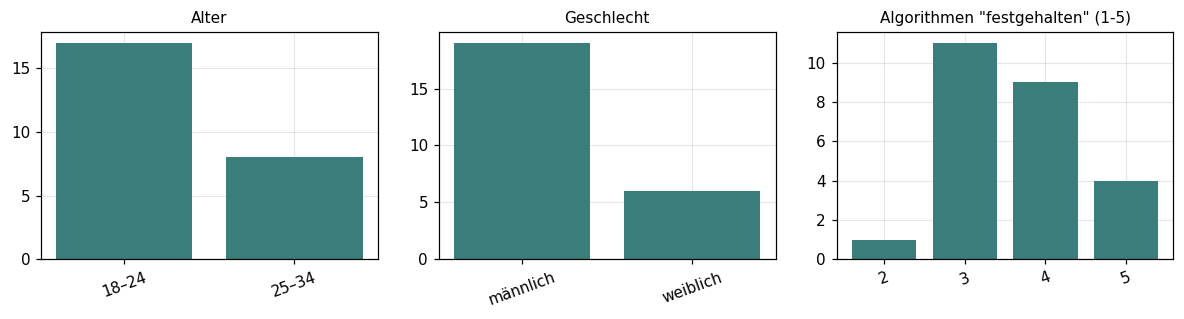

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
for a, (i, t) in zip(ax, [(3,'Alter'), (4,'Geschlecht'), (11,'Algorithmen "festgehalten" (1-5)')]):
    vc = df.iloc[:,i].replace('', np.nan).dropna().value_counts()
    vc = vc.sort_index() if i==11 else vc
    a.bar(vc.index.astype(str), vc.values, color=TEAL)
    a.set_title(t, fontsize=10); a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


In [6]:
# Mediennutzungs-Profil (Häufigkeitsskalen nie..täglich)
order = ['nie','selten','gelegentlich','oft','täglich']
media = {'klass. Radio': 6, 'Musik-Streaming': 7, 'algo. Plattformen': 8}
mt = pd.DataFrame({lbl: df.iloc[:,i].value_counts() for lbl,i in media.items()})
mt = mt.reindex(order).fillna(0).astype(int)
mt


,klass. Radio,Musik-Streaming,algo. Plattformen
nie,8,0,0
selten,10,0,0
gelegentlich,3,1,3
oft,2,2,6
täglich,2,22,16


Die Stichprobe ist jung (ganz überwiegend 18–34) und überwiegend männlich – typisch für eine ZHAW-Pilotstichprobe und entsprechend **nicht repräsentativ**. Auffällig: klassisches Radio wird selten genutzt, algorithmische Plattformen häufig – die Teilnehmenden bewerten Attune also vor dem Erfahrungshintergrund engagement-getriebener Medien.

## 2 · Machbarkeit

Ergänzt den technischen Machbarkeitsnachweis (Prototyp + Unit-Tests) um die **Nutzersicht**: Lief die Sendung durch, und wie wurde die technische Qualität erlebt?

In [7]:
run = df.iloc[:,12].value_counts()
print('Lief die App fehlerfrei?'); print(run.to_string())
print(f'\n=> {run.get("Ja, vollständig",0)}/{n} vollständig fehlerfrei.')


Lief die App fehlerfrei?
Lief die App von Anfang bis Ende ohne Fehler?
Ja, vollständig                  22
Teilweise – kleinere Probleme     3

=> 22/25 vollständig fehlerfrei.


In [8]:
tech = item_table([
    ('Audioqualität insgesamt', col(15)),
    ('Verständlichkeit KI-Moderation', col(16)),
    ('Natürlichkeit der Stimme', col(17)),
    ('Übergänge zwischen Elementen', col(18)),
    ('Reaktionszeit der App', col(19)),
])
tech


,M,SD,Min,Max,n
Audioqualität insgesamt,4.48,0.59,3.0,5.0,25.0
Verständlichkeit KI-Moderation,4.56,0.58,3.0,5.0,25.0
Natürlichkeit der Stimme,3.72,1.02,2.0,5.0,25.0
Übergänge zwischen Elementen,3.68,0.95,2.0,5.0,25.0
Reaktionszeit der App,4.25,0.74,3.0,5.0,24.0


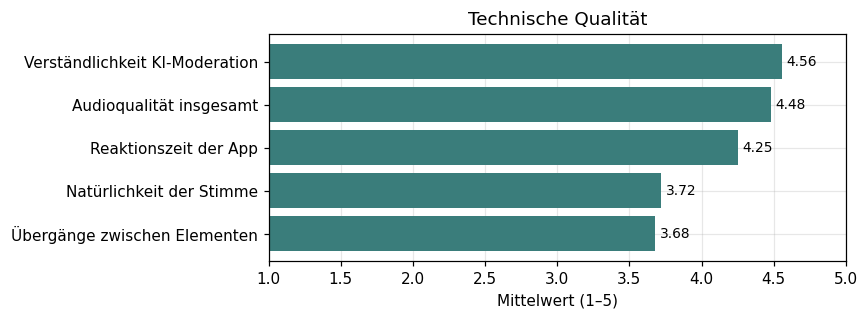

In [9]:
s = tech['M'].sort_values()
fig, ax = plt.subplots(figsize=(8,3))
ax.barh(s.index, s.values, color=TEAL)
ax.set_xlim(1,5); ax.set_xlabel('Mittelwert (1–5)'); ax.set_title('Technische Qualität')
for y,v in enumerate(s.values): ax.text(v+0.03, y, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


**Befund.** 22 von 25 Sendungen liefen vollständig fehlerfrei durch, die übrigen drei mit kleineren Problemen – der Machbarkeitsnachweis aus Nutzersicht ist damit erbracht. Audioqualität und Verständlichkeit der Moderation werden klar positiv bewertet; **Natürlichkeit der Stimme und Übergänge** sind die schwächsten technischen Punkte (≈ 3.7) und decken sich mit den Freitext-Hinweisen (abrupte Themenwechsel, Lautstärkesprung Musik↔Sendung, Stimme „leicht künstlich"). Einzelne gemeldete Probleme: Musik-Ruckeln beim ersten Song, falsche Endzeit-Anzeige, Jingle startete erst nach Pause/Play.

## 3 · Usability / Akzeptanz

### 3.1 · Bedienbarkeit – SUS-angelehnter Index

Die sechs Bedienbarkeits-Items sind **angelehnt an die System Usability Scale (Brooke 1996)**, umfassen aber bewusst nicht alle zehn Originalitems. Ein **standardkonformer SUS-Score (0–100) ist damit nicht ausweisbar**. Berichtet wird stattdessen ein klar als *adaptiert* gekennzeichneter Index plus die Einzelitems. Die negativ formulierten Items 2 („unnötig komplex") und 6 („musste viel lernen") werden umgepolt.

In [10]:
sus_items = [
    ('… regelmässig nutzen (pos)',        col(38), False),
    ('… unnötig komplex (neg, R)',        col(39), True),
    ('… einfach zu bedienen (pos)',       col(40), False),
    ('… schnell zurechtfinden (pos)',     col(41), False),
    ('… fühlte mich sicher (pos)',        col(42), False),
    ('… musste viel lernen (neg, R)',     col(43), True),
]
sus_tab = item_table([(lbl, s) for lbl, s, _ in sus_items])
display(sus_tab)

# Adaptierter Index: Negativitems umpolen, Mittel je Person, auf 0-100 skalieren
recoded = pd.concat([(6 - s) if r else s for _, s, r in sus_items], axis=1)
person_mean = recoded.mean(axis=1)
sus_index = (person_mean - 1) / 4 * 100
print(f'Adaptierter SUS-angelehnter Index: M = {sus_index.mean():.1f}  SD = {sus_index.std():.1f}  (0–100)')
print('Zur Einordnung (Bangor et al. 2008): >80 ~ "excellent / A". '
      'Wert ist wegen 6 statt 10 Items NICHT direkt mit Standard-SUS vergleichbar.')


,M,SD,Min,Max,n
… regelmässig nutzen (pos),3.20,1.19,1.0,5.0,25.0
"… unnötig komplex (neg, R)",1.52,0.87,1.0,4.0,25.0
… einfach zu bedienen (pos),4.56,0.58,3.0,5.0,25.0
… schnell zurechtfinden (pos),4.44,0.58,3.0,5.0,25.0
… fühlte mich sicher (pos),4.56,0.51,4.0,5.0,25.0
"… musste viel lernen (neg, R)",1.44,0.82,1.0,4.0,25.0


Adaptierter SUS-angelehnter Index: M = 82.5  SD = 12.7  (0–100)
Zur Einordnung (Bangor et al. 2008): >80 ~ "excellent / A". Wert ist wegen 6 statt 10 Items NICHT direkt mit Standard-SUS vergleichbar.


### 3.2 · Gesamteindruck – semantisches Differential (1–7)

Acht Gegensatzpaare (UEQ-artig), Skala **1–7**, höher = positiver Pol.

,M,SD,Min,Max,n
unangenehm – angenehm,5.96,0.89,4.0,7.0,25.0
unverständlich – verständlich,6.24,0.66,5.0,7.0,25.0
ineffizient – effizient,5.96,0.93,3.0,7.0,25.0
verwirrend – übersichtlich,5.92,1.00,3.0,7.0,25.0
langweilig – spannend,4.92,1.80,1.0,7.0,25.0
uninteressant – interessant,5.12,1.67,2.0,7.0,25.0
konventionell – originell,4.92,1.41,1.0,7.0,25.0
herkömmlich – neuartig,5.48,1.45,1.0,7.0,25.0


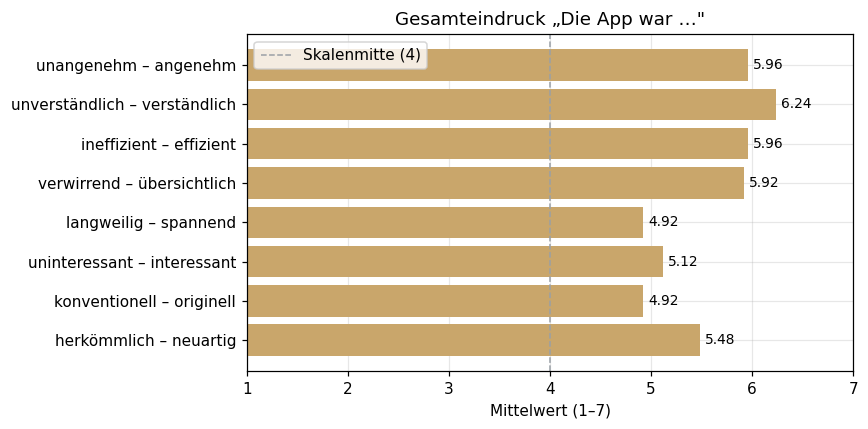

In [11]:
diff_pairs = [
    ('unangenehm – angenehm', 44),
    ('unverständlich – verständlich', 45),
    ('ineffizient – effizient', 46),
    ('verwirrend – übersichtlich', 47),
    ('langweilig – spannend', 48),
    ('uninteressant – interessant', 49),
    ('konventionell – originell', 50),
    ('herkömmlich – neuartig', 51),
]
diff_tab = item_table([(lbl, col(i)) for lbl, i in diff_pairs])
display(diff_tab)

fig, ax = plt.subplots(figsize=(8,4))
y = range(len(diff_pairs)); means = diff_tab['M'].values
ax.barh(list(y), means, color=SAND)
ax.set_yticks(list(y)); ax.set_yticklabels([p[0] for p in diff_pairs])
ax.set_xlim(1,7); ax.axvline(4, color=GREY, ls='--', lw=1, label='Skalenmitte (4)')
ax.set_xlabel('Mittelwert (1–7)'); ax.set_title('Gesamteindruck „Die App war …"'); ax.legend()
for yy,v in zip(y, means): ax.text(v+0.05, yy, f'{v:.2f}', va='center', fontsize=9)
ax.invert_yaxis(); plt.tight_layout(); plt.show()


**Befund.** Bedienbarkeit ist die **klare Stärke**: adaptierter Index ≈ 82, „einfach zu bedienen" und „fühlte mich sicher" je 4.56. Das pragmatische Differential (angenehm, verständlich, effizient, übersichtlich) liegt sehr hoch (≈ 6 von 7). Die hedonisch-innovativen Pole (spannend, interessant, originell) streuen stärker (SD ≈ 1.5–1.8): die App wird als gut bedienbar und neuartig, aber im *Erlebnis* unterschiedlich anregend wahrgenommen. Das einzige verhaltene Item – „kann mir vorstellen, regelmässig zu nutzen" (M = 3.20) – verweist auf die Akzeptanz-, nicht die Usability-Ebene (siehe Abschnitt 5).

### 3.3 · Eigenkonstruierte Einstellungs-Items

Items nach dem Schema *gefällt / unnötig / Wunsch* zu den Einstellungsmöglichkeiten sowie zum Sessionende.

In [12]:
setting = item_table([
    ('Themenauswahl hat gefallen', col(20)),
    ('Themenauswahl war unnötig (neg)', col(21)),
    ('mehr Optionen gewünscht', col(22)),
    ('Länge selbst wählen hat gefallen', col(24)),
    ('klares Ende angenehm', col(36)),
    ('gefehlt, dass nichts weiterlief (neg)', col(37)),
])
setting


,M,SD,Min,Max,n
Themenauswahl hat gefallen,3.80,0.87,2.0,5.0,25.0
Themenauswahl war unnötig (neg),2.28,0.98,1.0,4.0,25.0
mehr Optionen gewünscht,3.28,1.10,1.0,5.0,25.0
Länge selbst wählen hat gefallen,4.40,0.71,3.0,5.0,25.0
klares Ende angenehm,3.92,0.76,3.0,5.0,25.0
"gefehlt, dass nichts weiterlief (neg)",2.80,1.29,1.0,5.0,25.0


Die Möglichkeit, **Themen und Länge selbst zu wählen, gefällt sehr** (4.6 bzw. 4.6) und wird kaum als unnötig empfunden (1.4). Der Wunsch nach *mehr* Optionen ist mittelhoch (≈ 3.3) – konsistent mit den Freitexten (tiefere Themenauswahl, Musikgenre). Das **klare Sendungsende** wird als angenehm erlebt (4.0), und der Wunsch nach Autoplay-artigem Weiterlaufen ist niedrig (1.9) – das wohlbefindens-orientierte Session-Design (Baustein 4) wird also angenommen.

## 4 · Wirkung

Items sind zu Konstrukt-Skalen gebündelt und an die Theorie aus Kap. 2.3 angebunden. Berichtet wird der Skalenmittelwert (Mittel der personenweisen Item-Mittel) plus die Einzelitems.

In [13]:
def scale(name, specs):
    "specs: list of (label, series). Druckt Items + Skalenmittel, gibt Skalen-Serie."
    tab = item_table(specs)
    cols = pd.concat([s for _, s in specs], axis=1)
    sc = cols.mean(axis=1)
    print(f'### {name}  —  Skalen-M = {sc.mean():.2f}  (SD = {sc.std():.2f})')
    display(tab)
    return sc

scales = {}
scales['Selbstbestimmung (SDT-Autonomie)'] = scale('Selbstbestimmung · SDT-Autonomie (Ryan & Deci 2000)', [
    ('selbst bestimmen, was ich höre', col(61)),
    ('Hörwünsche respektiert', col(62)),
    ('an Bedürfnisse anpassbar', col(63)),
])


### Selbstbestimmung · SDT-Autonomie (Ryan & Deci 2000)  —  Skalen-M = 3.81  (SD = 0.84)


,M,SD,Min,Max,n
"selbst bestimmen, was ich höre",3.56,1.16,1.0,5.0,25.0
Hörwünsche respektiert,3.92,0.81,2.0,5.0,25.0
an Bedürfnisse anpassbar,3.96,0.89,2.0,5.0,25.0


In [14]:
scales['Kompetenz (SDT)'] = scale('Kompetenz · SDT', [
    ('App effektiv nutzen', col(64)),
    ('verstehe, wie Personalisierung zustande kommt', col(65)),
])
scales['Verbundenheit / Passung (SDT)'] = scale('Verbundenheit / Passung · SDT', [
    ('wirkte wie für mich gemacht', col(66)),
    ('fühlte mich angesprochen', col(67)),
])


### Kompetenz · SDT  —  Skalen-M = 3.98  (SD = 0.64)


,M,SD,Min,Max,n
App effektiv nutzen,3.96,0.89,2.0,5.0,25.0
"verstehe, wie Personalisierung zustande kommt",4.00,0.76,2.0,5.0,25.0


### Verbundenheit / Passung · SDT  —  Skalen-M = 3.54  (SD = 0.92)


,M,SD,Min,Max,n
wirkte wie für mich gemacht,3.56,1.04,2.0,5.0,25.0
fühlte mich angesprochen,3.52,1.05,2.0,5.0,25.0


In [15]:
scales['Wohlbefinden (Digital Wellbeing)'] = scale('Wohlbefinden · Digital Wellbeing (Vanden Abeele 2021)', [
    ('danach entspannter', col(68)),
    ('nicht ausbeuterisch (kein Sog)', col(69)),
    ('gesünder als Spotify/TikTok/YouTube', col(70)),
])
scales['Vergleich klass. Radio'] = scale('Vergleich zu klassischem Radio', [
    ('würde Attune bevorzugen', col(71)),
    ('deckt Bedürfnisse ab, die Radio nicht abdeckt', col(72)),
])


### Wohlbefinden · Digital Wellbeing (Vanden Abeele 2021)  —  Skalen-M = 3.37  (SD = 0.96)


,M,SD,Min,Max,n
danach entspannter,3.00,1.19,1.0,5.0,25.0
nicht ausbeuterisch (kein Sog),3.84,1.03,1.0,5.0,25.0
gesünder als Spotify/TikTok/YouTube,3.28,1.31,1.0,5.0,25.0


### Vergleich zu klassischem Radio  —  Skalen-M = 3.28  (SD = 1.21)


,M,SD,Min,Max,n
würde Attune bevorzugen,3.08,1.32,1.0,5.0,25.0
"deckt Bedürfnisse ab, die Radio nicht abdeckt",3.48,1.19,1.0,5.0,25.0


In [16]:
# Algorithmische Souveränität: "nicht gelenkt" ist bereits positiv gepolt
scales['Kontrolle / Souveränität'] = scale('Kontrolle über Personalisierung · Algorithmische Souveränität (Reviglio & Agosti 2020)', [
    ('verstand, warum Inhalte vorgeschlagen', col(74)),
    ('konnte Personalisierung kontrollieren', col(75)),
    ('fühlte mich nicht „gelenkt"', col(76)),
])
print('Werte der App (Wohlbefinden als Ziel spürbar):')
display(item_table([('Wohlbefinden ist erkennbar das Ziel', col(77))]))


### Kontrolle über Personalisierung · Algorithmische Souveränität (Reviglio & Agosti 2020)  —  Skalen-M = 3.49  (SD = 0.86)


,M,SD,Min,Max,n
"verstand, warum Inhalte vorgeschlagen",3.68,0.99,1.0,5.0,25.0
konnte Personalisierung kontrollieren,3.32,1.11,1.0,5.0,25.0
"fühlte mich nicht „gelenkt""",3.54,1.06,2.0,5.0,24.0


Werte der App (Wohlbefinden als Ziel spürbar):


,M,SD,Min,Max,n
Wohlbefinden ist erkennbar das Ziel,3.56,1.04,1.0,5.0,25.0


### 4.1 · Transparenz – Wahrnehmung und Nützlichkeit

Zuerst: Wurden die Transparenz-Elemente überhaupt **bemerkt**? Dann: Wie **hilfreich** sind sie?

In [17]:
perc = pd.DataFrame({
    'Quellenangaben': df.iloc[:,52].value_counts(),
    'Begründung Themen': df.iloc[:,53].value_counts(),
    'KI-Pipeline-Übersicht': df.iloc[:,54].value_counts(),
}).reindex(['Ja','Nein','Bin mir nicht sicher']).fillna(0).astype(int)
print('Wahrnehmung der Transparenz-Elemente:'); display(perc)

useful = scale('Nützlichkeit der Transparenz-Elemente', [
    ('Quellenangaben', col(55)),
    ('Begründung der Themenwahl', col(56)),
    ('Sichtbarkeit der KI-Pipeline', col(57)),
    ('Hinweis auf Grenzen der KI', col(58)),
])
scales['Transparenz-Nützlichkeit'] = useful


Wahrnehmung der Transparenz-Elemente:


,Quellenangaben,Begründung Themen,KI-Pipeline-Übersicht
Ja,14,8,16
Nein,7,12,7
Bin mir nicht sicher,4,5,2


### Nützlichkeit der Transparenz-Elemente  —  Skalen-M = 3.65  (SD = 0.61)


,M,SD,Min,Max,n
Quellenangaben,4.04,0.98,2.0,5.0,25.0
Begründung der Themenwahl,3.52,0.87,2.0,5.0,25.0
Sichtbarkeit der KI-Pipeline,3.60,0.91,2.0,5.0,25.0
Hinweis auf Grenzen der KI,3.46,0.98,1.0,5.0,24.0


### 4.2 · Kritische Reflexion – Filterblase, Bias, Grenzen

Hier ist Vorsicht bei der Interpretation geboten: einige Items messen **erwünschtes Bewusstsein**, nicht eine Schwäche der App.

In [18]:
print('Filterblase / Themenblase:')
display(item_table([
    ('bewusst: Medien können Sicht einschränken (Awareness)', col(78)),
    ('Gefühl, in Themenblase zu landen (neg)', col(79)),
    ('Themenauswahl wirkte ausgewogen', col(80)),
    ('auch Infos ausserhalb der Bubble', col(81)),
]))
print('\nBias in der KI-Moderation:')
display(item_table([
    ('voreingenommene Aussagen bemerkt (neg)', col(82)),
    ('KI sollte Quellen/Grenzen transparent machen (Norm)', col(83)),
]))
print('\nGrenzen der App (Awareness, hoch = erwünscht):')
display(item_table([
    ('klar, was App leistet und was nicht', col(84)),
    ('würde der KI nicht blind vertrauen', col(85)),
]))


Filterblase / Themenblase:


,M,SD,Min,Max,n
bewusst: Medien können Sicht einschränken (Awareness),4.08,0.64,3.0,5.0,25.0
"Gefühl, in Themenblase zu landen (neg)",3.00,0.96,1.0,5.0,25.0
Themenauswahl wirkte ausgewogen,3.64,0.76,2.0,5.0,25.0
auch Infos ausserhalb der Bubble,3.40,0.96,1.0,5.0,25.0



Bias in der KI-Moderation:


,M,SD,Min,Max,n
voreingenommene Aussagen bemerkt (neg),2.60,1.08,1.0,5.0,25.0
KI sollte Quellen/Grenzen transparent machen (Norm),3.84,1.25,1.0,5.0,25.0



Grenzen der App (Awareness, hoch = erwünscht):


,M,SD,Min,Max,n
"klar, was App leistet und was nicht",3.84,0.62,3.0,5.0,25.0
würde der KI nicht blind vertrauen,4.20,0.76,2.0,5.0,25.0


### 4.3 · Wirkungs-Überblick

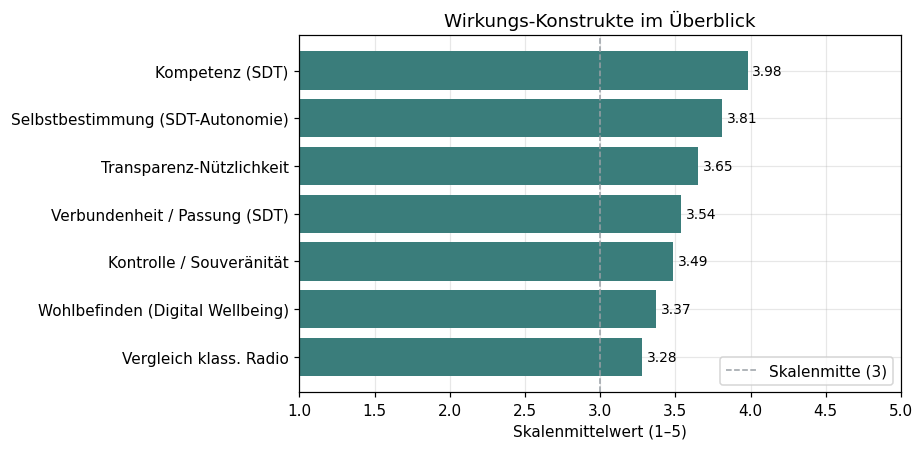

In [19]:
ov = pd.Series({k: v.mean() for k, v in scales.items()}).sort_values()
fig, ax = plt.subplots(figsize=(8.5,4.2))
ax.barh(ov.index, ov.values, color=TEAL)
ax.set_xlim(1,5); ax.axvline(3, color=GREY, ls='--', lw=1, label='Skalenmitte (3)')
ax.set_xlabel('Skalenmittelwert (1–5)'); ax.set_title('Wirkungs-Konstrukte im Überblick'); ax.legend()
for y,v in enumerate(ov.values): ax.text(v+0.03, y, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


**Befund.** Die **kompetenz- und autonomienahen Konstrukte sind am stärksten**: Kompetenz (3.98) und Selbstbestimmung (3.81) liegen deutlich über der Skalenmitte – die methodische Pointe (Personalisierung *mit* statt *gegen* die Nutzerautonomie) zeigt sich in den Daten. **Verbundenheit/Passung (3.54)**, **Kontrolle/Souveränität (3.49)** und **Wohlbefinden (3.37)** sind moderat positiv. Am verhaltensten: **Vergleich zum klassischen Radio (3.28)** und innerhalb des Wohlbefindens das Item „danach entspannter" (3.00) – ein einmaliger Erstkontakt erzeugt noch keinen klaren Entspannungseffekt, was die im Studienkonzept angelegte Längsschnitt-Idee stützt.

Bei der **Transparenz** zeigt sich eine Lücke zwischen *Vorhandensein* und *Wahrnehmung*: die KI-Pipeline-Übersicht wurde mehrheitlich bemerkt, die **Begründung der Themenwahl jedoch von der Mehrheit nicht** – als hilfreich gelten die Elemente aber durchweg (3.5–4.0). Hinweis für die Diskussion: Transparenz wirkt nur, wenn sie auch auffällt.

Die **kritische Reflexion** funktioniert wie intendiert: Filterblasen-Bewusstsein ist hoch, das Gefühl, *tatsächlich* in einer Blase zu landen, niedrig; voreingenommene Aussagen wurden kaum bemerkt; die normative Erwartung „eine KI sollte ihre Grenzen transparent machen" ist sehr hoch.

## 5 · Weiternutzungsabsicht

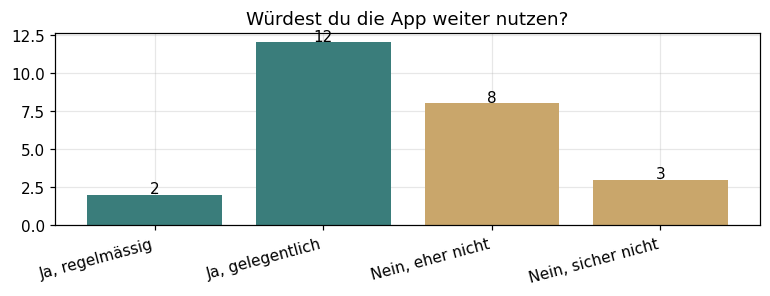

Ja (regelmässig/gelegentlich): 14/25   |   Nein: 11/25


In [20]:
wn_order = ['Ja, regelmässig','Ja, gelegentlich','Nein, eher nicht','Nein, sicher nicht']
wn = df.iloc[:,89].value_counts().reindex(wn_order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(7,2.8))
colors = [TEAL, TEAL, SAND, SAND]
ax.bar(range(len(wn)), wn.values, color=colors)
ax.set_xticks(range(len(wn))); ax.set_xticklabels(wn_order, rotation=15, ha='right')
ax.set_title('Würdest du die App weiter nutzen?')
for x,v in enumerate(wn.values): ax.text(x, v+0.1, str(v), ha='center')
plt.tight_layout(); plt.show()
print(f'Ja (regelmässig/gelegentlich): {wn[:2].sum()}/{n}   |   Nein: {wn[2:].sum()}/{n}')


Die Weiternutzungsabsicht ist **geteilt** (14 ja / 11 nein) – im Einklang mit dem verhaltenen Item „regelmässig nutzen" (3.20). Die Freitexte erklären die Spaltung: Befürworter nennen Personalisierung und Selbstbestimmung, Ablehnende vor allem **KI-Skepsis** und die Präferenz für „herkömmliches Radio" sowie fehlende native App / Smartphone-Verfügbarkeit. Akzeptanz ist hier also weniger eine Usability- als eine **Werte- und Distributionsfrage**.

## 6 · Qualitative Auswertung der Freitexte

Die offenen Felder wurden induktiv zu Themen-Clustern verdichtet. Jede Nennung wurde einem oder mehreren Clustern zugeordnet; angegeben sind Häufigkeit (Anzahl Nennungen) und je ein wörtliches **Ankerzitat**. Die folgende Code-Zelle stellt die ausgezählten Rohnennungen zur Nachvollziehbarkeit bereit.

In [21]:
open_cols = {14:'Techn. Probleme', 23:'Wunsch Themenauswahl', 25:'Fehlende Einstellung',
             32:'Falsche Aussage', 73:'Attraktiver vs. Radio', 86:'Besonders gefallen',
             87:'Gestört', 88:'Wunsch', 90:'Begründung Weiternutzung'}
for i, lbl in open_cols.items():
    vals = [v.strip() for v in df.iloc[:,i] if v.strip() and v.strip().lower() not in
            ('nein','-','keine','nichts','nein keine','keine.','nichts.')]
    print(f'— {lbl}: {len([v for v in df.iloc[:,i] if v.strip()])} Antworten, '
          f'davon {len(vals)} mit Inhalt')


— Techn. Probleme: 12 Antworten, davon 4 mit Inhalt
— Wunsch Themenauswahl: 11 Antworten, davon 11 mit Inhalt
— Fehlende Einstellung: 3 Antworten, davon 3 mit Inhalt
— Falsche Aussage: 2 Antworten, davon 2 mit Inhalt
— Attraktiver vs. Radio: 10 Antworten, davon 10 mit Inhalt
— Besonders gefallen: 22 Antworten, davon 22 mit Inhalt
— Gestört: 20 Antworten, davon 15 mit Inhalt
— Wunsch: 18 Antworten, davon 17 mit Inhalt
— Begründung Weiternutzung: 5 Antworten, davon 5 mit Inhalt


### 6.1 · Was besonders gefallen hat  *(22 Nennungen)*

| Cluster | ≈ Nennungen | Ankerzitat |
|---|---|---|
| **Personalisierung / eigene Themen- & Längenwahl** | ~10 | *„Die ganze Struktur (Themenauswahl und die Länge selber entscheiden können)"* |
| Echtheit / Aktualität der Daten (Wetter, News, lokal) | ~4 | *„Die Echtheit der Daten (Wetter, News etc.)"* |
| Innovation / Idee des personalisierten Radios | ~3 | *„Sehr Innovativ!"* |
| Einfache Bedienung & Design | ~3 | *„Einfache Bedienung und Navigation"* |
| Transparenz (Sektionsanzeige, Quellen, Übersicht) | ~2 | *„… laufend sehen welche Sektion als nächstes abläuft … Erklärungen und Quellen geben mir ein sicheres Gefühl"* |
| Moderationsstil / kompakter Aufbau | ~2 | *„… der lockere Moderationsstil hat die Sendung natürlicher wirken lassen"* |

### 6.2 · Was gestört hat  *(20 Nennungen)*

| Cluster | ≈ Nennungen | Ankerzitat |
|---|---|---|
| **Nichts / keine Störung** | ~6 | *„ich hatte keine Störfaktoren"* |
| **Musik (Geschmack, Qualität, keine Genre-Wahl)** | ~5 | *„die schlechte Musik … eventuell Musikrichtung noch selber entscheiden können"* |
| Themen (Tiefe, Genauigkeit, Erwartung) | ~5 | *„Die News haben meine Erwartungen nicht erfüllt."* |
| Technik (Übergänge, Lautstärkesprung, künstliche Stimme) | ~3 | *„Zwischen dem Wechsel von Musik und Sendung gab es einen plötzlich grossen Unterschied in der Lautstärke"* |
| Grundsätzliche KI-/Radio-Skepsis | ~2 | *„Ich höre nie Radio und Nachrichten, somit hätte die App nicht so viele Vorteile für mich."* |

### 6.3 · Wünsche  *(18 Nennungen)*

| Cluster | ≈ Nennungen | Ankerzitat |
|---|---|---|
| **Tiefere / mehr Themen- und Personalisierungs-Optionen** | ~7 | *„… dass man die Themen noch stärker personalisieren kann …"* |
| Musikgenre selbst wählen | ~3 | *„eigene Einstellung für seine Lieblings-Musikgenres"* |
| Native App / Plattform / Dark Mode | ~3 | *„das es auch für iPhone verfügbar ist"* |
| Preis / Monetarisierung | ~2 | *„zwischen 5–7 Franken im Monat wäre ich dafür bereit auszugeben"* |
| Mehr/bessere Transparenz (Quellen in-app) | ~2 | *„Bessere Transparenz, woher die KI die Informationen hat."* |

### 6.4 · Hinweis für die Diskussion: Faktentreue

Ein Teilnehmer meldete eine **inhaltlich falsche Moderationsaussage**: *„Es stand, dass FC St. Gallen gestern Abend gewonnen hatte, dabei war es vor 2 Stunden …"*. Auch wenn die Glaubwürdigkeits-Items insgesamt positiv ausfielen, belegt dieser Fall konkret die Notwendigkeit des Halluzinations-/Aktualitäts-Guards in der Moderations-Pipeline und gehört in die Diskussion der Grenzen (Kap. 10).

## 7 · Kernbefunde (Synthese)

**Machbarkeit.** Erbracht – 22/25 Sendungen fehlerfrei; Audioqualität und Verständlichkeit stark, Stimmnatürlichkeit und Übergänge sind die technischen Schwachstellen.

**Usability / Akzeptanz.** Stärkster Bereich: adaptierter SUS-Index ≈ 82, sehr gute Werte für Bedienbarkeit und das pragmatische Gesamteindrucks-Profil. Selbst-Wahl von Thema und Länge wird breit geschätzt.

**Wirkung.** Kompetenz und Selbstbestimmung am höchsten – die wohlbefindens-orientierte Personalisierung *mit* Nutzerautonomie zeigt Wirkung. Verbundenheit, Souveränität und Wohlbefinden moderat positiv; Entspannung und Radio-Vergleich am verhaltensten (Erstkontakt-Effekt → stützt Längsschnitt-Idee). Transparenz gilt als hilfreich, wird aber teils nicht bemerkt. Kritische Reflexion funktioniert wie intendiert.

**Akzeptanz-Spaltung.** Weiternutzung 14 ja / 11 nein – getrieben weniger von Usability als von KI-Werthaltung und fehlender nativer App.

**Top-Verbesserungshebel aus den Freitexten:** (1) tiefere Themen-/Unterthemen-Auswahl, (2) Musikgenre-Wahl, (3) sanftere Übergänge/Lautstärke-Angleichung, (4) Faktentreue der Moderation, (5) native App / Distribution.

> Diese Synthese bildet die Grundlage für den Ergebnisteil (Kap. 8) und die Diskussion (Kap. 10), die dieselbe Dreiteilung aufgreifen.